In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'oob_score'])
Data = namedtuple('Data', ['X','y'])
parameters = Params(3, 0.3, 25, False)


import sys
sys.path.append('../library')

import classification_rf
from importlib import reload
reload(classification_rf)

import rf_wrapper_functions as rfwrap

np.random.seed(24)

In [7]:
from sklearn.impute import SimpleImputer
DATA_DIR = "../Input_Data/Heart_Disease_Data/Processed_Data"


#import Cleveland Data
processed_cleveland_data = pd.read_csv(f"{DATA_DIR}/processed.cleveland.data", delimiter=",", na_values=["?"], header=None).to_numpy()
processed_cleveland_data = np.delete(processed_cleveland_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
cleveland = imputer.fit_transform(processed_cleveland_data)

#add label column
cleveland = np.insert(cleveland, -1, [0]*len(cleveland), axis = 1)

processed_hungarian_data = pd.read_csv(f"{DATA_DIR}/processed.hungarian.data", delimiter=",", na_values=["?"], header=None).to_numpy()
processed_hungarian_data = np.delete(processed_hungarian_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
hungary = imputer.fit_transform(processed_hungarian_data)
#add label column
hungary = np.insert(hungary, -1, [1]*len(hungary), axis = 1)

processed_switzerland_data = pd.read_csv(f"{DATA_DIR}/processed.switzerland.data", delimiter=",", na_values=["?"], header=None).to_numpy()
processed_switzerland_data = np.delete(processed_switzerland_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
switzerland = imputer.fit_transform(processed_switzerland_data)
#add label column
switzerland = np.insert(switzerland, -1, [2]*len(switzerland), axis = 1)

processed_va_data = pd.read_csv(f"{DATA_DIR}/processed.va.data", delimiter=",", na_values=["?"], header=None).to_numpy()
processed_va_data = np.delete(processed_va_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
va = imputer.fit_transform(processed_va_data)
#add label column
va = np.insert(va, -1, [3]*len(va), axis = 1)

#data = np.vstack((processed_cleveland_data, processed_hungarian_data, processed_switzerland_data, processed_va_data))
data = np.vstack((cleveland, hungary, switzerland, va))

X = data[:,0:-1]
y = data[:,-1]
y[y != 0] = 1
y = y.astype(int)

In [8]:
X_train, X_test, y_train, y_test = rfwrap.split_by_source(X, y, test_size=0.2, random_state=24)
dataset = Dataset(X_train, X_test, y_train, y_test)
data = Data(X,y)

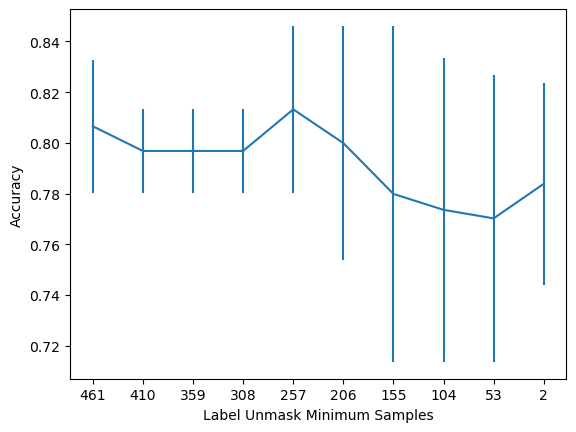

In [ ]:
parameters = Params(2, 0.3, 25, False)

accuracy_score, rf, source_score, source_size, X_tests, y_tests = rfwrap.msl_errorbars_kfold_data(
    n_folds = 10,
    n_estimators=500, 
    n_forests=20,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

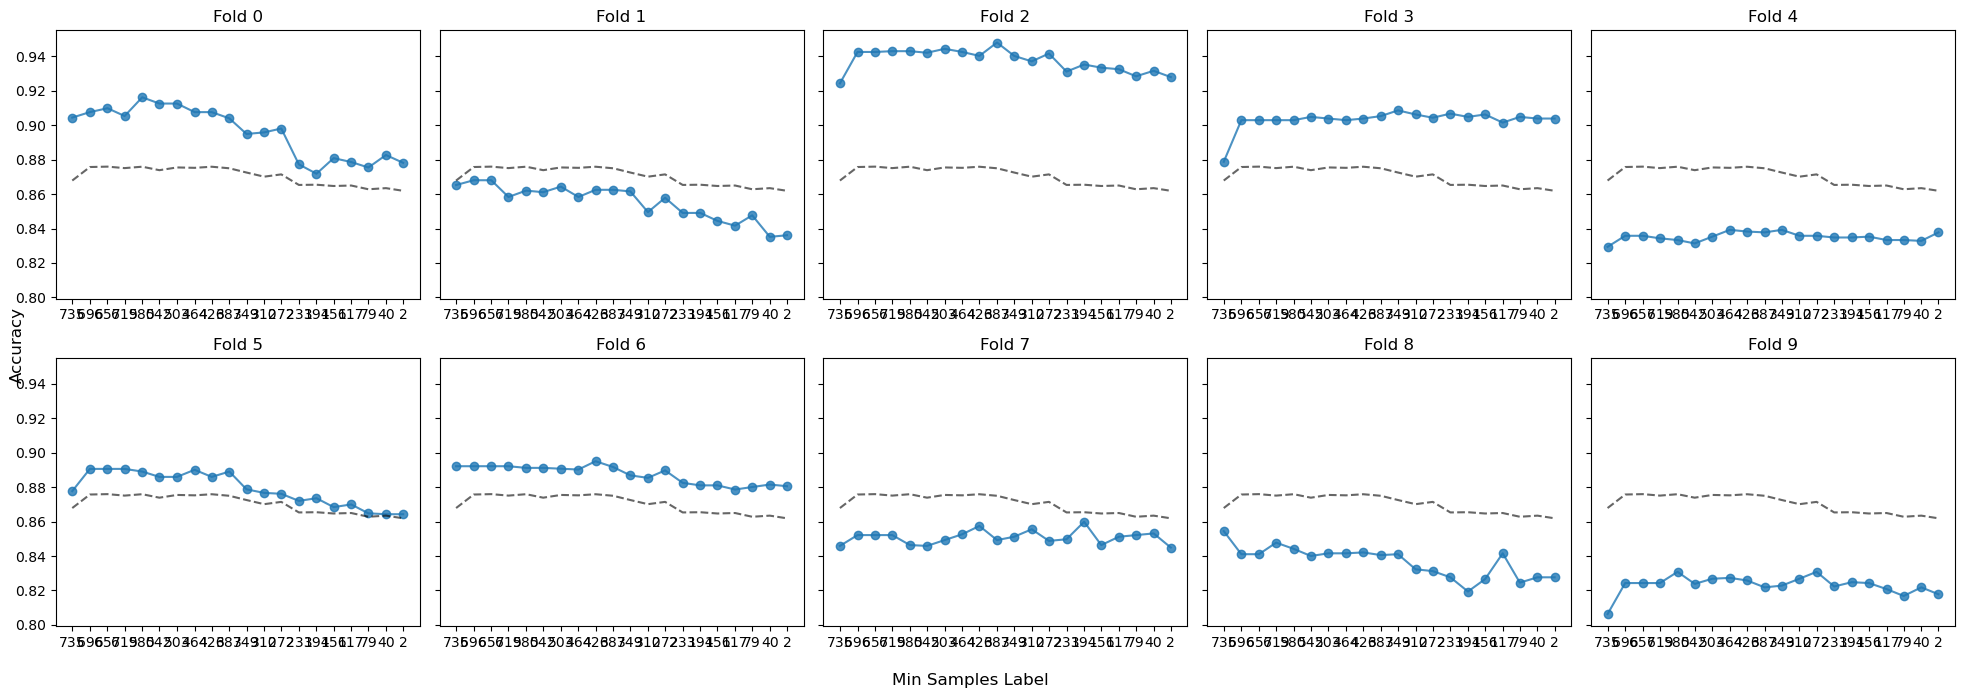

In [28]:
rfwrap.plot_forests_by_fold(accuracy_score, dataset, parameters, depth_type = "msl")

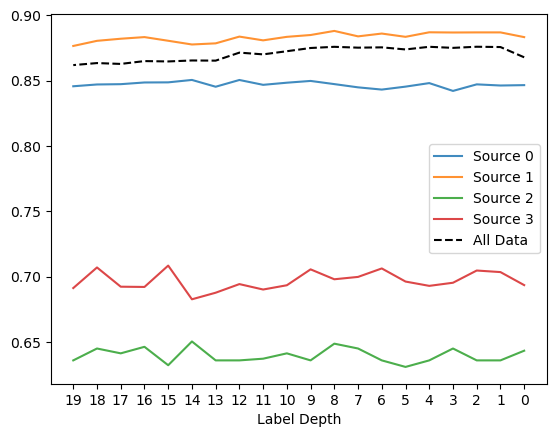

In [30]:
rfwrap.plot_forests(accuracy_score,source_score, sourced= True, show_error=False)

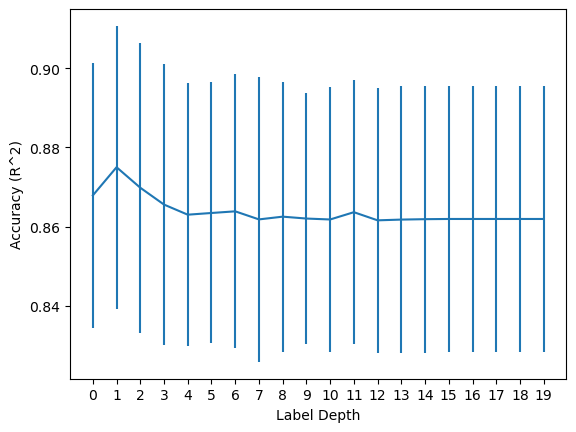

In [26]:
accuracy_score1, rf1, source_score1, source_size1, X_tests1, y_tests1 = rfwrap.errorbars_kfold_data(
    n_folds = 10,
    n_estimators=500, 
    depth=20,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

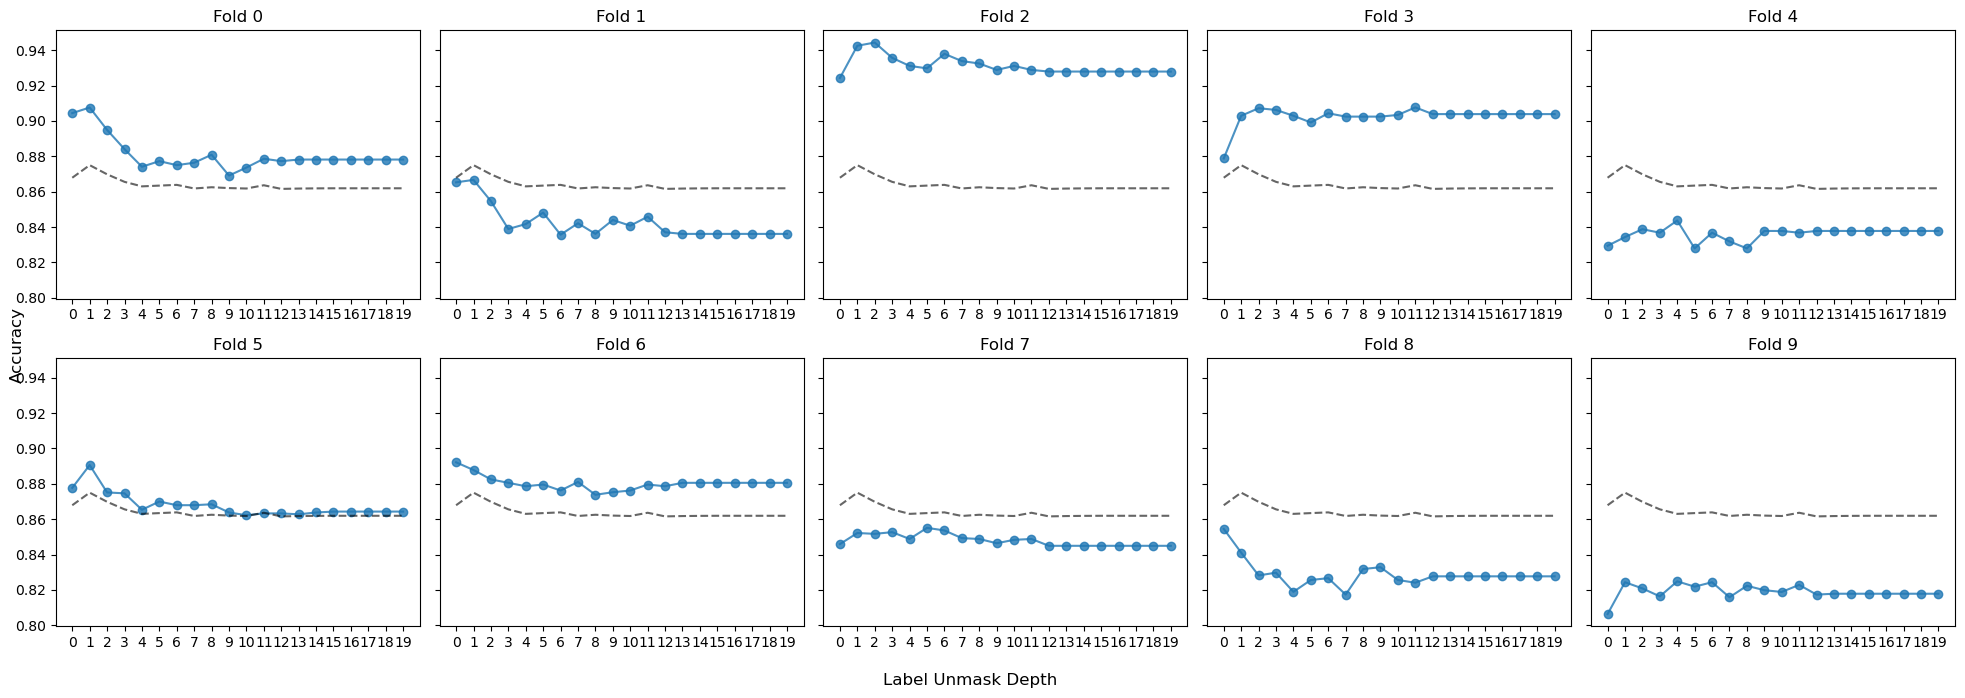

In [27]:
rfwrap.plot_forests_by_fold(accuracy_score1, dataset, parameters, depth_type = "depth")

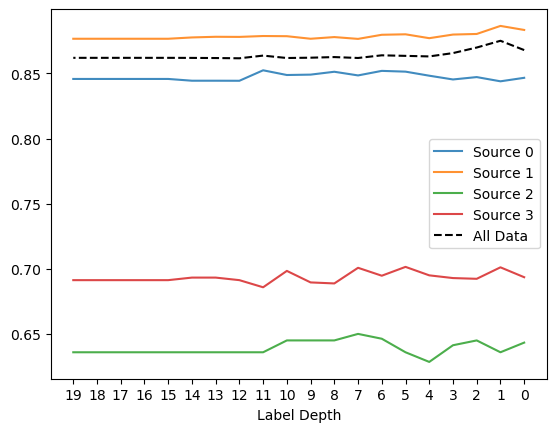

In [32]:
rfwrap.plot_forests(accuracy_score1,source_score1, sourced= True, show_error=False)